In [1]:
import pandas as pd 
df=pd.read_csv('adult.csv')

In [14]:
import numpy as np    
# For optimization
from scipy.optimize import Bounds, BFGS                     
from scipy.optimize import LinearConstraint, minimize   
# For plotting
import matplotlib.pyplot as plt
import seaborn as sns
# For generating dataset
import sklearn.datasets as dt

In [25]:
ZERO = 1e-7

In [185]:
dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])
m,n=dat.shape
C=10
alpha_0 = np.random.rand(m)*C
alpha_0

array([5.07657001, 3.20974928, 3.69082517, 5.0325689 , 5.14014013,
       8.57916766, 8.42414556, 5.82765157, 5.64099935, 6.62803206])

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


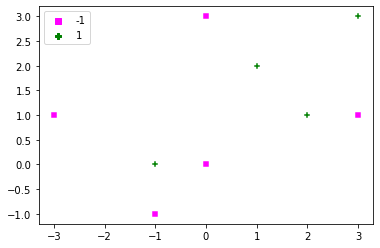

In [168]:
dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])


def plot_x(x, t, alpha=[], C=0):
    sns.scatterplot(dat[:,0], dat[:, 1], style=labels,
    hue=labels, markers=['s', 'P'],
    palette=['magenta', 'green'])
    if len(alpha) > 0:
        alpha_str = np.char.mod('%.1f', np.round(alpha, 1))
        ind_sv = np.where(alpha > ZERO)[0]
        for i in ind_sv:   
            plt.gca().text(dat[i,0], dat[i, 1]-.25, alpha_str[i] )

                  
plot_x(dat, labels)

In [17]:
# def alpha1_optimize(C,eta):
#     m,n=dat.shape
#     alpha_0 = np.random.rand(m)*C   
#     l=np.zeros(m)
#     n=len(alpha_0)
#     f=[]
    
#     for i in range(0,3):
#         for index_i,i in enumerate(alpha_0):

#             for index_k,k in enumerate(alpha_0):
                

#                 K= np.dot(dat[index_i, :], dat[index_k, :])
                
#                 result=0

#                 for index_i2,i2 in enumerate(alpha_0):

#                     result  += alpha_0[index_i2]*labels[index_i2]*K
#                     # print(result)
            
#                 alpha_0[index_k] += eta*(1-labels[index_k]*(result))
            
#                 if alpha_0[index_k] < 0:
#                     alpha_0[index_k]=0
#                 if alpha_0[index_k] > C :
#                     alpha_0[index_k] = C
                
#                 else:
#                     alpha_0[index_k]=alpha_0[index_k]
                
                
                

   
#     return(np.array(alpha_0))
# alpha=alpha1_optimize(10,0.4)
# alpha


In [ ]:

def alpha1_optimize(C,eta,Kernel,sigma):
    m,n=dat.shape
    
    for index_i,i in enumerate(alpha_0): 
        
        # Optimizng single alpha value for each data point
        for index_k,k in enumerate(alpha_0):

            if Kernel==1:

                # linear kernel
                K= np.dot(dat[index_i, :], dat[index_k, :])
                # Guassian Kernel

            elif Kernel==2:
                magnitude = np.linalg.norm(dat[index_i:] - dat[index_k,:])

                K=np.exp((-magnitude**2)/(2*(sigma**2))) 
            
            sum=0

            for i2 in alpha_0:

                sum  += alpha_0[index_i]*labels[index_i]*K

            
            alpha_0[index_k] += eta*(1-labels[index_k]*(sum))
        # print(alpha_0)

    if alpha_0[index_i] < 0:
        alpha_0[index_i]=0
    if alpha_0[index_i] > C :
        alpha_0[index_i] = C
    else:
    alpha_0[index_i]=alpha_0[index_i]
            
    
    
      
    return(np.array(alpha_0))



alpha=alpha1_optimize(9,0.2,1,10)
alpha

# alpha_0=np.array([0.71801222, 0.42167596, 0.92104793, 0.19844114, 0.64025391 ,0.45301235,
#  0.72016174, 0.42261659, 0.69100532, 0.2])
# print(alpha_0)
# for C in range(99,103):   
#     print(alpha_0)
#     alpha_0=alpha1_optimize(alpha_0,C,0.3,1,4)



# yk  \sum yi ai K(xi,xj)
# -1/2 y^j \sum yi ai K(xi,xj)    (summing over second x)
# -1/2 y^i \sum yj aj  K(xi,xj)   (where i is value j had above)

In [425]:

def alpha0_optimize(dat,alpha_0,C,eta,Kernel,sigma):
    m,n=dat.shape
    
    for index_i,i in enumerate(alpha_0): 
        
        # Optimizng single alpha value for each data point
        for index_k,k in enumerate(alpha_0):

            if Kernel==1:

                # linear kernel
                K= np.dot(dat[index_i, :], dat[index_k, :])
                # Guassian Kernel

            elif Kernel==2:
                magnitude = np.linalg.norm(dat[index_i:] - dat[index_k,:])

                K=np.exp((-magnitude**2)/(2*(sigma**2))) 
            
            sum=0

            for index_i,i in enumerate(alpha_0):

                sum  += alpha_0[index_i]*labels[index_i]*K

            alpha_0[index_k] += eta*(1-labels[index_k]*(sum))
            
    # for index_k,k in enumerate(alpha_0):   
    #     if alpha_0[index_k] < 0:
    #         alpha_0[index_k]=0
    #     if alpha_0[index_k] > C :
    #         alpha_0[index_k] = C
    #     else:
    #         alpha_0[index_k]=alpha_0[index_k]


    return(np.array(alpha_0))



def alpha_all_optimize(dat,alpha_0,C,eta,Kernel,sigma):
    m,n=dat.shape
    alpha_all=np.zeros([m+1,m])
    i=0
    K=1
    while i <m:
        if i==0:
            alpha_all[0]=alpha_0
            
            alpha_all[i+1]=alpha0_optimize(dat,alpha_all[i],C,eta,Kernel,sigma)
            

        else:
            
            alpha_all[i+1]=alpha0_optimize(dat,alpha_all[i],C,eta,Kernel,sigma)
            
        i+=1
        
    return np.array(alpha_all[-1])

alpha_0=np.array([3.22204476, 2.6848115 , 7.41587949, 9.72114515, 6.06148403,
       6.44464601, 9.83009215, 6.94054486, 7.07334534, 5.13343589])
    
alpha_all_optimize(dat,alpha_0,C=10,eta=0.01,Kernel=1,sigma=10)

array([ 5.31191316,  3.6848115 ,  9.59567669, 11.24564984,  8.49779267,
        7.44464601, 11.26577244,  7.46179417,  7.57895717,  4.6047663 ])

In [383]:
def U_L_bound(C,alpha_updated):
    for index_i,i in enumerate(alpha_updated):
        if alpha_updated[index_i] < 0:
            alpha_updated[index_i]=0
        if alpha_updated[index_i] > C :
            alpha_updated[index_i] = C
        else:
            alpha_updated[index_i]=alpha_updated[index_i]
    return np.array(alpha_updated)
        
# U_L_bound(100,alpha_updated)

In [384]:
sum_pos=0
sum_neg=0

for index,i in enumerate(alpha_updated):
    if labels[index] == 1:
        sum_pos += alpha_updated[index]*labels[index]
        
    elif labels[index] == -1:
        sum_neg += alpha_updated[index]*labels[index]


ratio=   sum_neg/sum_pos
print(ratio)

for index,i in enumerate(alpha_updated):
    if labels[index] == 1:
        sum_pos += alpha_updated[index]*labels[index]
        
    elif labels[index] == -1:
        sum_neg += alpha_updated[index]*labels[index]
print(sum_pos, sum_neg)

-0.9966571782166616
54.54884840192505 -54.36650132323107


In [385]:
def get_w(alpha, t, x):
    m = len(x)
    # Get all support vectors
    w = np.zeros(x.shape[1])
    for i in range(m):
        w = w + alpha[i]*t[i]*x[i, :]        
    return w

def get_w0(alpha, t, x, w, C):
    C_numeric = C-ZERO
    # Indices of support vectors with alpha<C
    # ind_sv = np.where((alpha > ZERO)&(alpha < C_numeric))[0]
    w0 = 0.0
    # print(ind_sv)
    for index,s in enumerate(alpha):
        w0 = w0 + t[index] - np.dot(x[index, :], w)
    # Take the average    
    w0 = w0 / len(alpha)
    return w0

In [418]:
def classify_points(x_test, w, w0):
    # get y(x_test)
    predicted_labels = np.sum(x_test*w, axis=1) +w0
    predicted_labels = np.sign(predicted_labels)
    # Assign a label arbitrarily a +1 if it is zero
    predicted_labels[predicted_labels==0] = 1
    return predicted_labels

def misclassification_rate(labels, predictions):
    total = len(labels)
    errors = sum(labels != predictions)
    return errors/total*100

In [419]:
def plot_hyperplane(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    y_coord = -w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, y_coord, color='red')

def plot_margin(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    ypos_coord = 1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, ypos_coord, '--', color='green') 
    yneg_coord = -1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, yneg_coord, '--', color='magenta')

[188.62187379 302.87970092]
-469.1923607093464
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]


/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


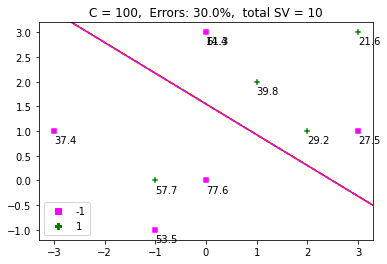

In [424]:
def display_SVM_result(x,t,alpha_0,C,eta,Kernel,sigma):
    # Get the alphas
    eta=0.4
    
    alpha_unbound=alpha_all_optimize(dat,alpha_0,C,eta,Kernel,sigma)
    alpha=U_L_bound(C,alpha_unbound)
    
    # Get the weights
    w = get_w(alpha, t, x)
    print(w)
    w0 = get_w0(alpha, t, x, w, C)
    print(w0)

    plot_x(x, t, alpha, C)
    xlim = plt.gca().get_xlim()
    
    ylim = plt.gca().get_ylim()
    plot_hyperplane(w, w0)
    plot_margin(w, w0)
    plt.xlim(xlim)
    plt.ylim(ylim)
    # Get the misclassification error and display it as title
    predictions = classify_points(x, w, w0)
    print(predictions)
    err = misclassification_rate(t, predictions)
    title = 'C = ' + str(C) + ',  Errors: ' + '{:.1f}'.format(err) + '%'
    title = title + ',  total SV = ' + str(len(alpha[alpha > ZERO]))
    plt.title(title)
    
alpha_0=np.array([5.07657001, 3.20974928, 3.69082517, 5.0325689 , 5.14014013,
       8.57916766, 8.42414556, 5.82765157, 5.64099935, 6.62803206])   

dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])

display_SVM_result(dat,labels,alpha_0,100,0.9,2,5)    
plt.show()


For different C values

In [403]:

alpha_unbound=alpha_all_optimize(dat,alpha_0,10,0.9,1,5)
print(alpha_unbound)
ind_sv = np.where((alpha > ZERO)&(alpha_unbound < 10))[0]
ind_sv


[nan nan nan nan nan nan nan nan nan nan]


/var/folders/55/2r1z4ynd3cvg9g75p1jdfzch0000gn/T/ipykernel_19597/3742812504.py:24: RuntimeWarning: overflow encountered in double_scalars
  sum  += alpha_0[index_i]*labels[index_i]*K
/var/folders/55/2r1z4ynd3cvg9g75p1jdfzch0000gn/T/ipykernel_19597/3742812504.py:24: RuntimeWarning: invalid value encountered in double_scalars
  sum  += alpha_0[index_i]*labels[index_i]*K


array([], dtype=int64)

In [390]:
alpha

array([-7.52688063e+16,  2.20890467e+14, -5.04000946e+16, -2.55313830e+16,
       -7.59314776e+16,  1.10000000e+01, -2.53104831e+16,  2.44270878e+16,
        2.57135886e+16,  7.08799110e+16])

10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]
10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]


/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]
10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]


/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]
10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]
10


/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]
10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(



10
[ 1. -1.  1.  1.  1. -1. -1. -1.  1.  1.]


/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


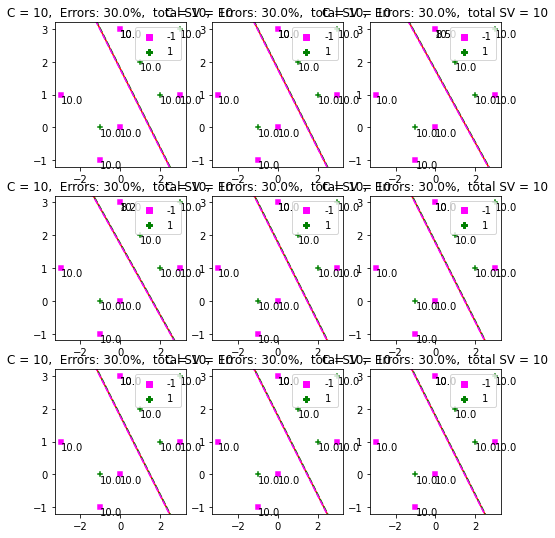

In [413]:
alpha_0=np.array([0.71801222, 0.42167596, 0.92104793, 0.19844114, 0.64025391,
       0.45301235, 0.72016174, 0.42261659, 0.69100532, 0.59047548])
alpha_0
dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])
fig = plt.figure(figsize=(8,25))

i=0
C_array = [-1,0.3,3,4,20,40,60,80,2000]

for C in C_array:
    fig.add_subplot(831+i)  
    
    display_SVM_result(dat,labels,alpha_0,10,0.5,2,C)  
    i = i + 1